<a href="https://colab.research.google.com/github/maggiecrowner/DS5001-Final-Project/blob/main/Riffs1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Riff 1

In [1]:
! git clone https://github.com/maggiecrowner/DS5001-Final-Project.git

Cloning into 'DS5001-Final-Project'...
remote: Enumerating objects: 224, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 224 (delta 25), reused 4 (delta 4), pack-reused 175 (from 1)
Receiving objects: 100% (224/224), 14.59 MiB | 11.77 MiB/s, done.
Resolving deltas: 100% (76/76), done.


In [2]:
!wget -O CORPUS.csv "https://virginia.box.com/shared/static/ijkqovrdgvrmctsdqobymig2p98q9x0m.csv"
!wget -O LIB.csv "https://virginia.box.com/shared/static/fhzudg34je9xls5bfcbi4xdnaiek74rj.csv"
!wget -O TSNE.csv "https://virginia.box.com/shared/static/rquke7qx0ne3jvvyp8512h6rqjjtg81c.csv"
!wget -O THETA.csv "https://virginia.box.com/shared/static/xap24wuixe7l1gm0xnhywtddmfmij38e.csv"

--2026-04-20 14:05:48--  https://virginia.box.com/shared/static/ijkqovrdgvrmctsdqobymig2p98q9x0m.csv
Resolving virginia.box.com (virginia.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to virginia.box.com (virginia.box.com)|74.112.186.157|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /public/static/ijkqovrdgvrmctsdqobymig2p98q9x0m.csv [following]
--2026-04-20 14:05:48--  https://virginia.box.com/public/static/ijkqovrdgvrmctsdqobymig2p98q9x0m.csv
Reusing existing connection to virginia.box.com:443.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://virginia.app.box.com/public/static/ijkqovrdgvrmctsdqobymig2p98q9x0m.csv [following]
--2026-04-20 14:05:48--  https://virginia.app.box.com/public/static/ijkqovrdgvrmctsdqobymig2p98q9x0m.csv
Resolving virginia.app.box.com (virginia.app.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to virginia.app.box.com (virginia.app.box.com)|74.112.186.157|:443.

In [7]:
import pandas as pd
CORPUS = pd.read_csv('CORPUS.csv', delimiter='|', index_col=[0,1,2,3])
LIB = pd.read_csv('LIB.csv', delimiter='|', index_col=0)
TSNE = pd.read_csv('TSNE.csv', delimiter='|', index_col=0)
THETA = pd.read_csv('THETA.csv', delimiter='|', index_col=[0,1,2])

In [12]:
# Check what the indices look like
print("THETA index:", THETA.index.name, THETA.index[:5])
print("LIB index:  ", LIB.index.name, LIB.index[:5])

THETA index: None MultiIndex([('Ariana Grande', '13 (Original Broadway Cast Recording)', ...),
            ('Ariana Grande',                         'Ariana Grande', ...),
            ('Ariana Grande',                         'Ariana Grande', ...),
            ('Ariana Grande',                         'Ariana Grande', ...),
            ('Ariana Grande',                         'Ariana Grande', ...)],
           names=['Artist', 'Album', 'Title'])
LIB index:   track_id Index(['Post Malone — ​​rockstar (beerbongs & bentleys)',
       'Post Malone — White Iverson (Stoney (Deluxe))',
       'Post Malone — Congratulations (Stoney (Deluxe))',
       'Post Malone — Psycho (beerbongs & bentleys)',
       'Post Malone — I Fall Apart (Stoney (Deluxe))'],
      dtype='object', name='track_id')


## Heatmap of Mean Topic Weight by Decade vs Topic

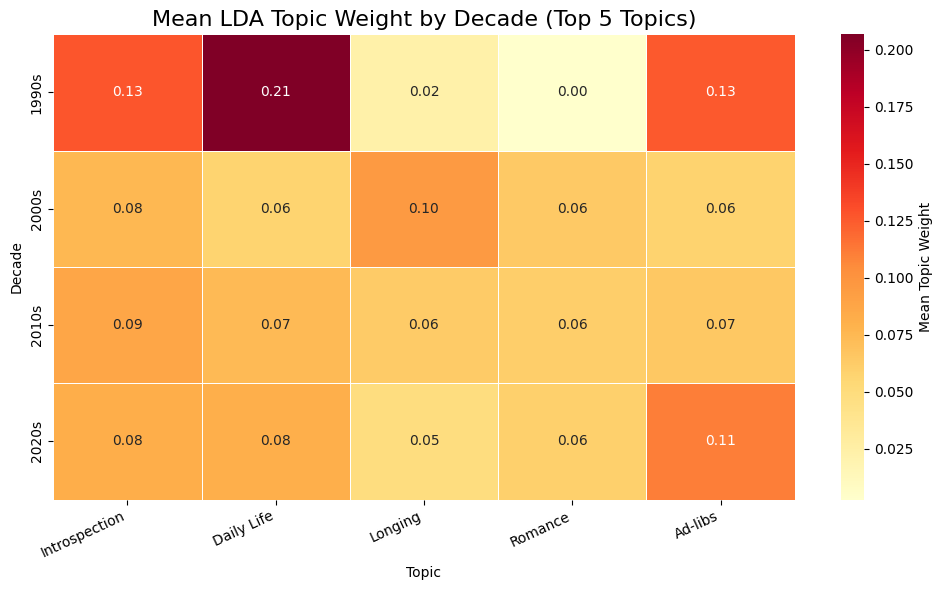

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

TOP_5 = ['T18', 'T02', 'T07', 'T13', 'T06']
theta_dec = THETA[TOP_5].copy()
theta_dec.index = [f"{artist} — {title} ({album})" for artist, album, title in THETA.index]
theta_dec.index.name = 'track_id'
theta_dec = theta_dec.join(LIB['Decade'])

TOPIC_NAMES = {
    'T18': 'Introspection',
    'T02': 'Daily Life',
    'T07': 'Longing',
    'T13': 'Romance',
    'T06': 'Ad-libs',
}

heatmap_data = theta_dec.groupby('Decade').mean()
heatmap_data = heatmap_data.rename(columns=TOPIC_NAMES)

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Mean Topic Weight'}
)
plt.title('Mean LDA Topic Weight by Decade (Top 5 Topics)', fontsize=16)
plt.xlabel('Topic')
plt.ylabel('Decade')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('heatmap_topic_by_decade.png', dpi=150)
plt.show()